In [2]:
import pycolmap as pcm
from pathlib import Path
import numpy as np, glob, cv2, matplotlib.pyplot as plt, time

In [6]:
path = Path(r"C:\Users\hiro\Desktop\colmap_4.0.4\building\dense\0\sparse")
out_path = Path(r"C:\Users\hiro\Desktop\colmap_4.0.4\building_masked")
masks_path = r'C:\Users\hiro\Desktop\colmap_4.0.4\building\images\masks'
reconstr = pcm.Reconstruction()
reconstr.read(path=path)
images = reconstr.images

In [18]:
def get_ponits_ids_outside_mask(images):
    point_scores = {}
    for image_id in images:
        for point in images[image_id].points2D:
            point_scores[point.point3D_id] = 0




    for image_id in images:
        image_mask_name = images[image_id].name.lower() + ".png"
        mask_path = glob.glob(masks_path + fr"\{image_mask_name}")[0]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        for point in images[image_id].points2D:
            point_2d = np.array(point.xy, dtype=int)

            inside_mask = mask[point_2d[1],point_2d[0]] == 1
            if inside_mask:
                point_scores[point.point3D_id] +=1
    for key in list(point_scores.keys()):
        if point_scores[key] != 0:
            del point_scores[key]
    return point_scores
point_to_delete = get_ponits_ids_outside_mask(images)


In [20]:
#point_to_delete = get_ponits_ids_outside_mask(images)
for point_id in point_to_delete.keys():
    reconstr.delete_point3D(point_id)

In [22]:
reconstr.write(r"C:\Users\hiro\Desktop\colmap_4.0.4\building_masked")

In [21]:
len(reconstr.points3D)

88178

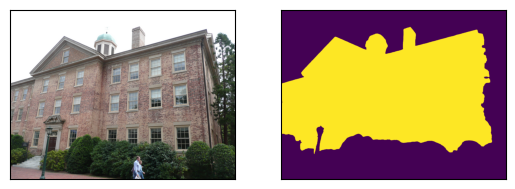

In [28]:
images_path = r"C:\Users\hiro\Desktop\colmap_4.0.4\building\images"
img_name = images_path+r"\rgb\P1180218.JPG"
mask_name = images_path+r"\masks\P1180218.jpg.png"
img = cv2.imread(img_name, cv2.IMREAD_COLOR_RGB)
mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)

f = plt.figure()
f.add_subplot(1,2, 1)
plt.xticks([])
plt.yticks([])
plt.imshow(img)
f.add_subplot(1,2, 2)
plt.xticks([])
plt.yticks([])
plt.imshow(mask)
plt.show(block=True)


In [108]:
points = reconstr.points3D
for point_id in points:
    break
point = points[9521]
p_w = point.xyz

In [4]:
point.track.elements

[TrackElement(image_id=11, point2D_idx=4819),
 TrackElement(image_id=9, point2D_idx=5929),
 TrackElement(image_id=20, point2D_idx=6627),
 TrackElement(image_id=10, point2D_idx=5209)]

In [4]:
for image  in reconstr.images.items():
    pass

In [6]:
images_count = len(images)

In [7]:
for image_id in images:
    print(images[image_id])

Image(image_id=1, camera_id=1, frame_id=1, name="P1180169.JPG", has_pose=1, triangulated=3510/8323)
Image(image_id=9, camera_id=1, frame_id=9, name="P1180170.JPG", has_pose=1, triangulated=4813/8368)
Image(image_id=19, camera_id=1, frame_id=19, name="P1180171.JPG", has_pose=1, triangulated=4738/7260)
Image(image_id=11, camera_id=1, frame_id=11, name="P1180174.JPG", has_pose=1, triangulated=5151/9291)
Image(image_id=12, camera_id=1, frame_id=12, name="P1180175.JPG", has_pose=1, triangulated=4050/10772)
Image(image_id=20, camera_id=1, frame_id=20, name="P1180172.JPG", has_pose=1, triangulated=4420/6764)
Image(image_id=10, camera_id=1, frame_id=10, name="P1180173.JPG", has_pose=1, triangulated=3411/5663)
Image(image_id=13, camera_id=1, frame_id=13, name="P1180176.JPG", has_pose=1, triangulated=5329/11026)
Image(image_id=14, camera_id=1, frame_id=14, name="P1180177.JPG", has_pose=1, triangulated=4425/6730)
Image(image_id=15, camera_id=1, frame_id=15, name="P1180178.JPG", has_pose=1, triang

In [8]:
camera = reconstr.cameras[1]

In [21]:
fc_l = (camera.focal_length_x, camera.focal_length_y)
skew = 0
pp_u, pp_v = camera.principal_point_x, camera.principal_point_y
K = np.array([[fc_l[0], skew, pp_u],
              [0, fc_l[1], pp_u],
              [0, 0, 1]])
img_id = 1
image=reconstr.images[img_id]
pose = image.cam_from_world()
R = pose.rotation.matrix()
t = pose.translation
p3D_cam = R @ p_w + t
p2D_hom = K @ p3D_cam


In [22]:
frames = reconstr.frames

In [23]:
image.cam_from_world()

Rigid3d(rotation_xyzw=[0.0255736, 0.0396925, -0.00728019, 0.998858], translation=[1.04982, 0.132734, 0.217222])

In [24]:
u = p2D_hom[1] / p2D_hom[2]
v = p2D_hom[0] / p2D_hom[2]

In [25]:
camera.img_from_cam(p3D_cam)


array([ 664.33235719, 1059.6365012 ])